# CRVSE Phase B - Ensemble rPPG - CRVSENET (Round 1)

### What this notebook does

Trains CRVSENet on ensemble rPPG signals (POS + CHROM + GREEN)
Runs **two Optuna studies** to isolate the contribution of multi-channel input:

| Study | INPUT_MODE | IN_CHANNELS | Signal |
|-------|------------|-------------|--------|
| 1 | `ensemble_only` | 1 | Pre-fused quality-weighted ensemble |
| 2 | `multichannel` | 3 | Stacked [POS, CHROM, GREEN] |

Both studies share one pre-built `all_samples` index.
The final model is trained on the winning study's best configuration.

## 1. Imports & Config

In [1]:
import h5py, torch, os, optuna
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy import stats
from scipy.signal import resample
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from tqdm import tqdm
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from collections import Counter

#  Paths 
H5_PATHS = {
    "mcd_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/mcd_rppg_ensemble.h5",
    "ubfc_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ubfc_rppg_ensemble.h5",
    "ubfc_phys" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ubfc_phys_ensemble.h5",
    "ecg_fitness": "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ecg_fitness_ensemble.h5"
}

# SQI gates per dataset 
# Thresholds calibrated during preprocessing (see NB06/NB07/NB08).
# MCD-rPPG 0.10 : recalibrated (ensemble scale differs from POS-only)
# UBFC-rPPG 0.07: original threshold, clean lab conditions
# UBFC-Phys 0.05: lowered - 35fps + 1024x1024 + stress tasks lower spectral SQI
DATASET_SQI_THRESHOLDS = {
    "mcd_rppg"  : 0.10,
    "ubfc_rppg" : 0.07,
    "ubfc_phys" : 0.05,
    "ecg_fitness" : 0.07
}

# Fixed config
MODEL_NAME = "CRVSENet_Ensemble"
HR_MIN = 40.0
HR_MAX = 180.0
MAX_NAN_FRAC = 0.10
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tuning config  
N_TRIALS = 50
N_EPOCHS = 50
BATCH_SIZE = 32
PRUNER_WARMUP = 5

# Study configs ─
# Two studies share one pre-built all_samples index.
# INPUT_MODE controls which signals __getitem__ assembles into the tensor.
STUDY_CONFIGS = {
    "ensemble_only" : {"in_channels": 1, "study_name": "crvse_b_ens_single"},
    "multichannel" : {"in_channels": 3, "study_name": "crvse_b_ens_multi"},
}

print(f"Device : {DEVICE}")
print(f"Trials : {N_TRIALS} | Max epochs/trial: {N_EPOCHS}")
print(f"Datasets : {list(H5_PATHS.keys())}")
print(f"SQI thresholds : {DATASET_SQI_THRESHOLDS}")
print(f"Studies : {list(STUDY_CONFIGS.keys())}")


Device : cuda
Trials : 50 | Max epochs/trial: 50
Datasets : ['mcd_rppg', 'ubfc_rppg', 'ubfc_phys', 'ecg_fitness']
SQI thresholds : {'mcd_rppg': 0.1, 'ubfc_rppg': 0.07, 'ubfc_phys': 0.05, 'ecg_fitness': 0.07}
Studies : ['ensemble_only', 'multichannel']


## 2. Window Extractor

In [2]:
def extract_windows(signals : dict, hr_cont : np.ndarray, fps: float, window_sec : int, stride_sec : int, 
                    target_frames : int, max_nan_frac : float, hr_min : float, hr_max : float) -> list:
    """
    Extract sliding windows from one recording.
    
    Returns:
        list of dicts, each containing:
            pos_win, chrom_win, green_win, ensemble_win: (target_frames,) float32
            hr_label: scalar float, nanmean of hr_cont over window
    """
    window_frames = int(fps * window_sec)
    stride_frames = int(fps * stride_sec)
    n_frames = len(hr_cont)
    results = []

    for start in range(0, n_frames - window_frames + 1, stride_frames):
        end = start + window_frames
        hr_win = hr_cont[start:end]

        # Gate 1: Nan fraction on HR label
        nan_frac = np.sum(np.isnan(hr_win)) / len(hr_win)
        if nan_frac > max_nan_frac:
            continue

        # Gate 2: scalar HR label
        hr_label = float(np.nanmean(hr_win))
        if not (hr_min <= hr_label <= hr_max):
            continue

        # Process each signal channel
        win_dict = {}
        skip = False

        for key in ("pos", "chrom", "green", "ensemble"):
            sig_win = signals[key][start:end]

            # Gate 3: NaN on signal
            if np.any(np.isnan(sig_win)):
                skip = True 
                break

            # Resample to fixed length
            if len(sig_win) != target_frames:
                sig_win = resample(sig_win, target_frames).astype(np.float32)

            # Gate 4: flat signal (std < 1e-6 means no pulse information)
            std = sig_win.std()
            if std < 1e-6:
                skip = True
                break

            # Z-score per window per channel
            sig_win = ((sig_win - sig_win.mean()) / std).astype(np.float32)
            win_dict[f"{key}_win"] = sig_win

        if skip:
            continue

        win_dict["hr_label"] = hr_label
        results.append(win_dict)

    return results

## 3. Index Builder

Reads all HDF5 files once and builds a flat list of window dicts. All four signal channels (POS, CHROM, GREEN, ensemble) are stored per window. SQI gating is applied per dataset before windowing.

In [3]:
def build_index(h5_paths: dict, sqi_thresholds: dict, window_sec: int, stride_sec: int, target_frames: int, 
                max_nan_frac: float, hr_min: float, hr_max: float) -> tuple:
    """
    Builds flat window index from all ensemble HDF5 files.
    
    SQI gate: recordings with sqi_ensemble < sqi_thresholds[dataset] are skipped.
    Threshold is dataset-specific - calibrated in preprocessing NBs.
    
    Returns:
        samples : list of window dicts (all_channels pre-computed)
        subject_keys : sorted list of unique subject keys for split.
    """
    samples = []
    subject_keys = set()
    skipped_sqi = 0

    for dataset_name, path in h5_paths.items():
        if not os.path.exists(path):
            print(f"[WARN] Not found, skipping: {path}")
            continue

        sqi_gate = sqi_thresholds.get(dataset_name, 0.07)

        with h5py.File(path, "r") as file:
            subjects = file["subjects"]

            for subj_id in subjects.keys():
                subj_key = f"{dataset_name}__{subj_id}"
                subject_keys.add(subj_key)
                recordings = subjects[subj_id]["recordings"]

                for sess_id in recordings.keys():
                    rec = recordings[sess_id]

                    # SQI gate - skip recording before any signal read
                    sqi_ens = float(rec.attrs.get("sqi_ensemble", 1.0))
                    if sqi_ens < sqi_gate:
                        skipped_sqi += 1
                        continue

                    fps = float(rec.attrs["fps"])
                    hr_cont = rec["hr_continuous"][:]

                    # Read all four signals - stored for both study modes
                    signals = {
                        "pos" : rec["rppg_pos"][:],
                        "chrom" : rec["rppg_chrom"][:],
                        "green" : rec["rppg_green"][:],
                        "ensemble" : rec["rppg_ensemble"][:]
                    }

                    wins = extract_windows(signals, hr_cont, fps, window_sec, stride_sec, 
                                           target_frames, max_nan_frac, hr_min, hr_max)
                    for w in wins:
                        w["subject_key"] = subj_key
                        w["dataset"] = dataset_name
                        samples.append(w)

    print(f"Total windows extracted : {len(samples)}")
    print(f"Total unique subjects : {len(subject_keys)}")
    print(f"Recordings skipped (SQI) : {skipped_sqi}")

    # Per-dataset breakdown
    ds_counts = Counter(s["dataset"] for s in samples)
    print("\nPer-dataset window counts:")
    for ds, n in sorted(ds_counts.items()):
        print(f"{ds:<15} : {n:>6} windows")

    return samples, sorted(subject_keys)    

## 4. Subject-Level Train/Val/Test Split 


In [4]:
def subject_split(subject_keys: list, train_frac: float = 0.7, val_frac : float = 0.15, seed: int = 42) -> tuple:
    """
    Subject-level stratified split. 
    test_frac = 1 - train_frac - val_frac.
    """
    rng = np.random.default_rng(seed)
    keys = np.array(subject_keys)
    rng.shuffle(keys)

    n = len(keys)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_keys = set(keys[:n_train])
    val_keys = set(keys[n_train : n_train + n_val])
    test_keys = set(keys[n_train + n_val:])

    print(f"Train subjects : {len(train_keys)}")
    print(f"Val subjects : {len(val_keys)}")
    print(f"Test subjects : {len(test_keys)}")
    return train_keys, val_keys, test_keys

## 5. Dataset Class
Assemble the input tensor from pre-built window dicts based on `input_mode`:
* `ensemble_only` -> `(1, 240)` from `ensemble_win`
* `mutlichannel` -> `(3, 240)` stacked from `[pos_win, chrom_win, green_win]`

Both studies reuse the same `all_samples` - the dataset is rebuilt per study with the correct `input_mode` passed to the constructor.

In [5]:
class CRVSEDataset(Dataset):
    """
    PyTorch Dataset for CRVSE Phase b ensemble rPPG -> HR estimation.
    
    Args:
        samples: list of window dicts from build_index()
        subject_set: set of subject_key strings to include (train/val/test)
        input_mode : `ensemble_only` | `multichannel` controls which signals are assembled into the input tensor
        
    """
    def __init__(self, samples: list, subject_set: set, input_mode: str = "multichannel") -> None:
        self.input_mode = input_mode
        self.items = [s for s in samples if s["subject_key"] in subject_set]
        print(f"Dataset size: {len(self.items)} windows (mode={input_mode})")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx: int) -> tuple:
        item = self.items[idx]

        if self.input_mode == "ensemble_only":
            # Shape: (1, 240) - single pre-fused channel
            signal = torch.tensor(item["ensemble_win"], dtype=torch.float32).unsqueeze(0)
        else: # multichannel
            # Shape: (3, 240) - independent algorithm outputs
            signal = torch.stack([
                torch.tensor(item["pos_win"], dtype=torch.float32),
                torch.tensor(item["chrom_win"], dtype=torch.float32),
                torch.tensor(item["green_win"], dtype=torch.float32)
            ])

        label = torch.tensor(item["hr_label"], dtype=torch.float32)
        return signal, label

## 6. Model Architecture


In [6]:
class TCNBlock(nn.Module):
    """
    One dilated causal TCN block with residual connection.
    Causal padding ensures no future information leaks into the current timestep.
    """
    def __init__(self, in_channels : int, out_channels: int, kernel_size : int = 3, dilation : int = 1, 
                 dropout : float = 0.2) -> None:
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, dilation=dilation, padding=0)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, dilation=dilation, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.residual_proj = ( nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity())
        self._kernel_size = kernel_size
        self._dilation = dilation

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.residual_proj(x)
        causal_pad = (self._kernel_size - 1) * self._dilation

        out = F.pad(x, (causal_pad, 0))
        out = self.conv1(out)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.dropout(out)

        out = F.pad(out, (causal_pad, 0))
        out = self.conv2(out)
        out = self.bn2(out)
        out = F.relu(out)
        out = self.dropout(out)

        return F.relu(out + residual)


class CRVSENet(nn.Module):
    """
    1D CNN + TCN baseline for rPPG -> HR estimation.

    Architecture:
        Input (in_channels, 240)
            ↓
        Conv Encoder — 3x [Conv1d -> BN -> ReLU -> Dropout]
            ↓
        TCN Stack — tcn_layers x TCNBlock with exponential dilation
            ↓
        Global Average Pooling -> (tcn_channels,)
            ↓
        Regression Head — FC -> ReLU -> Dropout -> FC -> scalar BPM

    Phase B change vs Phase A:
        in_channels is no longer hardcoded to 1.
        Passed from make_objective closure — 1 for ensemble_only, 3 for multichannel.
    """
    def __init__(self, in_channels : int = 1, base_channels : int = 32, tcn_channels : int = 64, tcn_layers : int = 4, 
                 tcn_kernel : int = 3,dropout : float = 0.2, hr_min: float = 40.0, hr_max : float = 180.0) -> None:
        super().__init__()
        self.hr_min = hr_min
        self.hr_max = hr_max

        # Conv Encoder - extracts local pulse-wave features
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, base_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Conv1d(base_channels, base_channels * 2, kernel_size=5, padding=2),
            nn.BatchNorm1d(base_channels * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        
            nn.Conv1d(base_channels * 2, tcn_channels,kernel_size=3, padding=1),
            nn.BatchNorm1d(tcn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # TCN Stack — exponential dilation: 1, 2, 4, 8, ...
        # At 30fps, dilation=8 + kernel=3 covers ~0.7s context
        # Full stack covers dominant HR frequency range (0.7-3.5 Hz)
        tcn_blocks: list[nn.Module] = []
        for i in range(tcn_layers):
            tcn_blocks.append(TCNBlock(
                in_channels  = tcn_channels,
                out_channels = tcn_channels,
                kernel_size  = tcn_kernel,
                dilation = 2 ** i,
                dropout = dropout,
            ))
        self.tcn = nn.Sequential(*tcn_blocks)

        # Regression Head
        self.head = nn.Sequential(
            nn.Linear(tcn_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, in_channels, 240)
        out = self.encoder(x) # (B, tcn_channels, 240)
        out = self.tcn(out) # (B, tcn_channels, 240)
        out = out.mean(dim=-1) # (B, tcn_channels) — global avg pool
        out = self.head(out) # (B, 1)
        out = out.squeeze(-1) # (B,)

        # Clamp to physiological range at inference only
        # During training gradients flow freely through unclamped outputs
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out  # (B,) — HR in BPM

In [7]:
# Model sanity check

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("Single-channel sanity check (ensemble_only):")
m1 = CRVSENet(in_channels=1, base_channels=32, tcn_channels=64, tcn_layers=4, tcn_kernel=3, 
              dropout=0.2, hr_min=HR_MIN, hr_max=HR_MAX)
x1 = torch.randn(32, 1, 240)
with torch.no_grad():
    o1 = m1(x1)
print(f"Input : {x1.shape}")
print(f"Output : {o1.shape}")
print(f"Params : {count_parameters(m1):,}")

print()
print("Three-channel sanity check (multichannel):")
m3 = CRVSENet(in_channels=3, base_channels=32, tcn_channels=64, tcn_layers=4, tcn_kernel=3, 
              dropout=0.2, hr_min=HR_MIN, hr_max=HR_MAX)
x3 = torch.randn(32, 3, 240)
with torch.no_grad():
    o3 = m3(x3)
print(f"Input : {x3.shape}")
print(f"Output : {o3.shape}")
print(f"Params : {count_parameters(m3):,}")

print()
print("Architecture (3-channel):")
print(m3)
del m1, m3, x1, x3, o1, o3

Single-channel sanity check (ensemble_only):
Input : torch.Size([32, 1, 240])
Output : torch.Size([32])
Params : 125,185

Three-channel sanity check (multichannel):
Input : torch.Size([32, 3, 240])
Output : torch.Size([32])
Params : 125,633

Architecture (3-channel):
CRVSENet(
  (encoder): Sequential(
    (0): Conv1d(3, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
  )
  (tcn): Sequential(
    (0): TCNBlock(
      (conv1)

## 7. Data Preparation

Single `build_index` call - all four signals read once. Both studies reuse the same `all_samples` and splits. DataLoaders are rebuilt per study inside the study cell (different tensor shapes).

In [8]:
all_samples, all_subject_keys = build_index(
    h5_paths = H5_PATHS, 
    sqi_thresholds = DATASET_SQI_THRESHOLDS, 
    window_sec = 8, 
    stride_sec = 4, 
    target_frames= 240,
    max_nan_frac=MAX_NAN_FRAC, 
    hr_min=HR_MIN, 
    hr_max=HR_MAX
)

train_keys, val_keys, test_keys = subject_split(all_subject_keys, train_frac=0.70, val_frac=0.15, seed=SEED)


Total windows extracted : 19052
Total unique subjects : 479
Recordings skipped (SQI) : 246

Per-dataset window counts:
ecg_fitness     :    882 windows
mcd_rppg        :  11283 windows
ubfc_phys       :   6239 windows
ubfc_rppg       :    648 windows
Train subjects : 335
Val subjects : 71
Test subjects : 73


## 8. Evaluation Functions

In [9]:
def compute_subject_level_metrics(preds : np.ndarray, labels : np.ndarray, subject_ids: list) -> dict:
    """
    Aggregate window predictions per subject (mean),
    Compute metrics across subjects.
    Subject-level MAE is the standard rPPG benchmark metric.
    """
    subj_preds = defaultdict(list)
    subj_labels = defaultdict(list)

    for p, l, s in zip(preds, labels, subject_ids):
        subj_preds[s].append(p)
        subj_labels[s].append(l)

    subj_pred_mean = np.array([np.mean(v) for v in subj_preds.values()])
    subj_label_mean = np.array([np.mean(v) for v in subj_labels.values()])

    diff = subj_pred_mean - subj_label_mean
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    r, _ = stats.pearsonr(subj_pred_mean, subj_label_mean)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())

    print(f"\nSubject-level metrics (n={len(subj_pred_mean)} subjects):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"r : {r:.4f}")
    print(f"BA bias: {ba_bias:.2f} BPM")
    print(f"BA LoA : [{ba_bias - 1.96*ba_sd:.2f}, {ba_bias + 1.96*ba_sd:.2f}] BPM")

    return {
        "subj_mae": mae, 
        "subj_rmse": rmse,
        "subj_r": r, 
        "ba_bias": ba_bias,
        "ba_loa_lo": ba_bias - 1.96*ba_sd,
        "ba_loa_hi": ba_bias + 1.96*ba_sd,
        "n_subjects": len(subj_pred_mean),
    }


def coverage_metrics(preds : np.ndarray, labels: np.ndarray,) -> None:
    abs_err = np.abs(preds - labels)
    for threshold in [5, 10, 15]:
        pct = float(np.mean(abs_err < threshold) * 100)
        print(f"|error| < {threshold:>2} BPM : {pct:.1f}% of windows")


def per_dataset_metrics(preds : np.ndarray, labels : np.ndarray, dataset_ids: list) -> None:
    datasets = sorted(set(dataset_ids))
    print("\nPer-dataset breakdown:")
    print(f"{'Dataset':<15} {'n':>5} {'MAE':>8} {'RMSE':>8} {'r':>8}")
    print(f"{'-'*46}")

    for ds in datasets:
        mask = np.array([d == ds for d in dataset_ids])
        p, l = preds[mask], labels[mask]
        if len(p) < 2:
            continue
        mae = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        r, _  = stats.pearsonr(p, l)
        print(f"{ds:<15} {len(p):>5} {mae:>8.2f} {rmse:>8.2f} {r:>8.4f}")


def hr_stratified_metrics(preds : np.ndarray, labels: np.ndarray) -> None:
    bins = [(40, 65, "bradycardia/low"),
            (65, 85, "normal low"),
            (85, 100, "normal high"),
            (100, 180, "tachycardia/exercise")]

    print("\nHR-stratified metrics:")
    print(f"{'Range':<22} {'n':>5} {'MAE':>8} {'RMSE':>8}")
    print(f"{'-'*46}")

    for lo, hi, label in bins:
        mask = (labels >= lo) & (labels < hi)
        if mask.sum() < 2:
            continue
        p, l = preds[mask], labels[mask]
        mae = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        print(f"{label:<22} {mask.sum():>5} {mae:>8.2f} {rmse:>8.2f}")


def full_evaluation(preds: np.ndarray, labels : np.ndarray, subject_ids: list, dataset_ids: list, model_name : str = "Model") -> None:

    print(f"\n{'='*55}")
    print(f"FULL EVALUATION - {model_name}")
    print(f"{'='*55}")

    # Window-level
    diff = preds - labels
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mape = float(np.mean(np.abs(diff) / np.abs(labels)) * 100)
    r, pval = stats.pearsonr(preds, labels)
    ss_res = np.sum(diff ** 2)
    ss_tot = np.sum((labels - labels.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())
    loa_lo = ba_bias - 1.96 * ba_sd
    loa_hi = ba_bias + 1.96 * ba_sd

    print(f"\nWindow-level (n={len(preds)} windows):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"MAPE : {mape:.2f} %")
    print(f"Pearson r : {r:.4f}  (p={pval:.4f})")
    print(f"R² : {r2:.4f}")
    print(f"BA bias : {ba_bias:.2f} BPM")
    print(f"BA LoA : [{loa_lo:.2f}, {loa_hi:.2f}] BPM")

    # Coverage
    print()
    coverage_metrics(preds, labels)

    # Subject-level
    compute_subject_level_metrics(preds, labels, subject_ids)

    # Per-dataset
    per_dataset_metrics(preds, labels, dataset_ids)

    # HR-stratified
    hr_stratified_metrics(preds, labels)


## 9. Objective Factory 

In [10]:
def make_objective(in_channels: int, train_loader: DataLoader, val_loader: DataLoader) -> callable:
    """Returns an Optuna objective bound to the given in_channels and loaders."""
    def objective(trial: optuna.Trial) -> float:
        # Tier 1 - regularisation & optimizer
        lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.4)
        huber_delta = trial.suggest_float("huber_delta", 1.0, 10.0)

        # Tier 2 - architecture
        base_channels = trial.suggest_categorical("base_channels", [16, 32, 64, 128])
        tcn_channels = trial.suggest_categorical("tcn_channels", [32, 64, 128])
        tcn_layers = trial.suggest_int("tcn_layers", 2, 6)
        tcn_kernel = trial.suggest_categorical("tcn_kernel", [3, 5, 7])

        model = CRVSENet(
            in_channels = in_channels,
            base_channels = base_channels,
            tcn_channels = tcn_channels,
            tcn_layers = tcn_layers,
            tcn_kernel = tcn_kernel,
            dropout = dropout,
            hr_min = HR_MIN,
            hr_max = HR_MAX
        ).to(DEVICE)

        loss_function = nn.HuberLoss(delta=huber_delta)
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=lr/100)

        best_val_mae = float("inf")

        for epoch in range(1, N_EPOCHS + 1):
            model.train()
            for signals, labels in train_loader:
                signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                preds = model(signals)
                loss = loss_function(preds, labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            model.eval()
            total_mae = 0.0
            with torch.inference_mode():
                for signals, labels in val_loader:
                    signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                    preds = model(signals)
                    total_mae += torch.mean(torch.abs(preds - labels)).item()
            val_mae = total_mae / len(val_loader)
            scheduler.step()

            if val_mae < best_val_mae:
                best_val_mae = val_mae

            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_val_mae
        
    return objective

print("make_objective factory defined.")

make_objective factory defined.


## 10. Study 1 - `ensemble_only` (1 channel)

Baseline: pre-fused quality-weighted ensemble signal as single input channel. Establishes whether the ensemble fusion itself carries enough information.

In [11]:
INPUT_MODE_1 = "ensemble_only"
IN_CHANNELS_1 = STUDY_CONFIGS[INPUT_MODE_1]["in_channels"]
STUDY_NAME_1 = STUDY_CONFIGS[INPUT_MODE_1]["study_name"]

print(f"Study 1: {INPUT_MODE_1} | in_channels={IN_CHANNELS_1}")
print()

train_ds_1 = CRVSEDataset(all_samples, train_keys, input_mode=INPUT_MODE_1)
val_ds_1 = CRVSEDataset(all_samples, val_keys, input_mode=INPUT_MODE_1)
train_loader_1 = DataLoader(train_ds_1, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)
val_loader_1 = DataLoader(val_ds_1, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler_1 = TPESampler(seed=SEED)
pruner_1 = MedianPruner(n_startup_trials=5, n_warmup_steps=PRUNER_WARMUP, interval_steps=1)
study_1 = optuna.create_study(direction="minimize", sampler=sampler_1, pruner=pruner_1, study_name=STUDY_NAME_1)

def progress_callback_1(study: optuna.Study, trial: optuna.Trial) -> None:
    status = "PRUNED" if trial.state == optuna.trial.TrialState.PRUNED else f"{trial.value:.2f} BPM"
    print(
        f"Trial {trial.number:>3} | val MAE : {status:<12} | best : {study.best_value:.2f} BPM | "
        f"lr={trial.params.get('lr','?'):.1e} drop={trial.params.get('dropout','?'):.2f} "
        f"tcn_l={trial.params.get('tcn_layers','?')}"
    )

print(f"Starting {STUDY_NAME_1} - {N_TRIALS} trials, up to {N_EPOCHS} epochs each")
print(f"Pruner: MedianPruner (warmup={PRUNER_WARMUP}, startup=5)")
print("-" * 70)

study_1.optimize(make_objective(IN_CHANNELS_1, train_loader_1, val_loader_1),
                 n_trials=N_TRIALS, callbacks=[progress_callback_1], show_progress_bar=True)

print("\n" + "=" * 60)
print(f"STUDY 1 COMPLETE - {INPUT_MODE_1}")
print("=" * 60)
print(f"Best val MAE : {study_1.best_value:.2f} BPM")
print(f"Best trial : #{study_1.best_trial.number}")
print("Best params:")
for key, value in study_1.best_params.items():
    print(f"{key:<20} : {value}")
n_complete = len([t for t in study_1.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned = len([t for t in study_1.trials if t.state == optuna.trial.TrialState.PRUNED])
print(f"Completed : {n_complete} Pruned : {n_pruned}")

Study 1: ensemble_only | in_channels=1

Dataset size: 12954 windows (mode=ensemble_only)
Dataset size: 2992 windows (mode=ensemble_only)
Starting crvse_b_ens_single - 50 trials, up to 50 epochs each
Pruner: MedianPruner (warmup=5, startup=5)
----------------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

Trial   0 | val MAE : 9.49 BPM     | best : 9.49 BPM | lr=2.4e-04 drop=0.32 tcn_l=6
Trial   1 | val MAE : 9.69 BPM     | best : 9.49 BPM | lr=1.5e-04 drop=0.26 tcn_l=2
Trial   2 | val MAE : 9.21 BPM     | best : 9.21 BPM | lr=4.1e-04 drop=0.12 tcn_l=4
Trial   3 | val MAE : 9.55 BPM     | best : 9.21 BPM | lr=4.6e-04 drop=0.26 tcn_l=2
Trial   4 | val MAE : 10.45 BPM    | best : 9.21 BPM | lr=2.4e-04 drop=0.35 tcn_l=2
Trial   5 | val MAE : 9.03 BPM     | best : 9.03 BPM | lr=5.4e-04 drop=0.12 tcn_l=5
Trial   6 | val MAE : PRUNED       | best : 9.03 BPM | lr=1.3e-04 drop=0.33 tcn_l=5
Trial   7 | val MAE : PRUNED       | best : 9.03 BPM | lr=1.8e-04 drop=0.33 tcn_l=6
Trial   8 | val MAE : 9.12 BPM     | best : 9.03 BPM | lr=6.4e-04 drop=0.20 tcn_l=3
Trial   9 | val MAE : PRUNED       | best : 9.03 BPM | lr=2.1e-04 drop=0.31 tcn_l=5
Trial  10 | val MAE : 9.08 BPM     | best : 9.03 BPM | lr=9.3e-04 drop=0.10 tcn_l=4
Trial  11 | val MAE : 8.97 BPM     | best : 8.97 BPM | lr=9.0e-04 drop=0.10 

## 11. Study 2 - `multichannel` (3 channels)

Three independent algorithm outputs stacked as separate channels. Model learns when each algorithm is trustworthy - implicit SQI learning.

In [12]:
INPUT_MODE_2 = "multichannel"
IN_CHANNELS_2 = STUDY_CONFIGS[INPUT_MODE_2]["in_channels"]
STUDY_NAME_2 = STUDY_CONFIGS[INPUT_MODE_2]["study_name"]

print(f"Study 2: {INPUT_MODE_2} | in_channels={IN_CHANNELS_2}")
print()

train_ds_2 = CRVSEDataset(all_samples, train_keys, input_mode=INPUT_MODE_2)
val_ds_2 = CRVSEDataset(all_samples, val_keys, input_mode=INPUT_MODE_2)

train_loader_2 = DataLoader(train_ds_2, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)
val_loader_2 = DataLoader(val_ds_2, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

sampler_2 = TPESampler(seed=SEED)
pruner_2 = MedianPruner(n_startup_trials=5, n_warmup_steps=PRUNER_WARMUP, interval_steps=1)
study_2 = optuna.create_study(direction="minimize", sampler=sampler_2, pruner=pruner_2, study_name=STUDY_NAME_2)

def progress_callback_2(study: optuna.Study, trial: optuna.Trial) -> None:
    status = "PRUNED" if trial.state == optuna.trial.TrialState.PRUNED else f"{trial.value:.2f} BPM"
    print(
        f"Trial {trial.number:>3} | val MAE : {status:<12} | best : {study.best_value:.2f} BPM | "
        f"lr={trial.params.get('lr','?'):.1e} drop={trial.params.get('dropout','?'):.2f} "
        f"tcn_l={trial.params.get('tcn_layers','?')}"
    )

print(f"Starting {STUDY_NAME_2} - {N_TRIALS} trials, up to {N_EPOCHS} epoch each")
print(f"Pruner: MedianPruner (warmup={PRUNER_WARMUP}, startup=5)")
print("-" * 70)

study_2.optimize(make_objective(IN_CHANNELS_2, train_loader_2, val_loader_2),
                n_trials=N_TRIALS, callbacks=[progress_callback_2], show_progress_bar=True)

print("\n" + "=" * 60)
print(f"STUDY 2 COMPLETE - {INPUT_MODE_2}")
print("=" * 60)
print(f"Best val MAE : {study_2.best_value:.2f} BPM")
print(f"Best trial : #{study_2.best_trial.number}")
print("Best params:")
for key, value in study_2.best_params.items():
    print(f"{key:<20} : {value}")
n_complete = len([t for t in study_2.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned = len([t for t in study_2.trials if t.state == optuna.trial.TrialState.PRUNED])
print(f"Completed : {n_complete}  Pruned : {n_pruned}")

Study 2: multichannel | in_channels=3

Dataset size: 12954 windows (mode=multichannel)
Dataset size: 2992 windows (mode=multichannel)
Starting crvse_b_ens_multi - 50 trials, up to 50 epoch each
Pruner: MedianPruner (warmup=5, startup=5)
----------------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

Trial   0 | val MAE : 9.98 BPM     | best : 9.98 BPM | lr=2.4e-04 drop=0.32 tcn_l=6
Trial   1 | val MAE : 9.81 BPM     | best : 9.81 BPM | lr=1.5e-04 drop=0.26 tcn_l=2
Trial   2 | val MAE : 8.23 BPM     | best : 8.23 BPM | lr=4.1e-04 drop=0.12 tcn_l=4
Trial   3 | val MAE : 8.51 BPM     | best : 8.23 BPM | lr=4.6e-04 drop=0.26 tcn_l=2
Trial   4 | val MAE : 9.01 BPM     | best : 8.23 BPM | lr=2.4e-04 drop=0.35 tcn_l=2
Trial   5 | val MAE : 7.55 BPM     | best : 7.55 BPM | lr=5.4e-04 drop=0.12 tcn_l=5
Trial   6 | val MAE : PRUNED       | best : 7.55 BPM | lr=1.3e-04 drop=0.33 tcn_l=5
Trial   7 | val MAE : 8.70 BPM     | best : 7.55 BPM | lr=1.8e-04 drop=0.33 tcn_l=6
Trial   8 | val MAE : 8.11 BPM     | best : 7.55 BPM | lr=6.4e-04 drop=0.20 tcn_l=3
Trial   9 | val MAE : PRUNED       | best : 7.55 BPM | lr=2.1e-04 drop=0.31 tcn_l=5
Trial  10 | val MAE : 7.90 BPM     | best : 7.55 BPM | lr=9.3e-04 drop=0.10 tcn_l=4
Trial  11 | val MAE : 7.89 BPM     | best : 7.55 BPM | lr=9.0e-04 drop=0.10 

## 12. Study Comparison + Optuna Plots


Study 1 - ensemble_only:


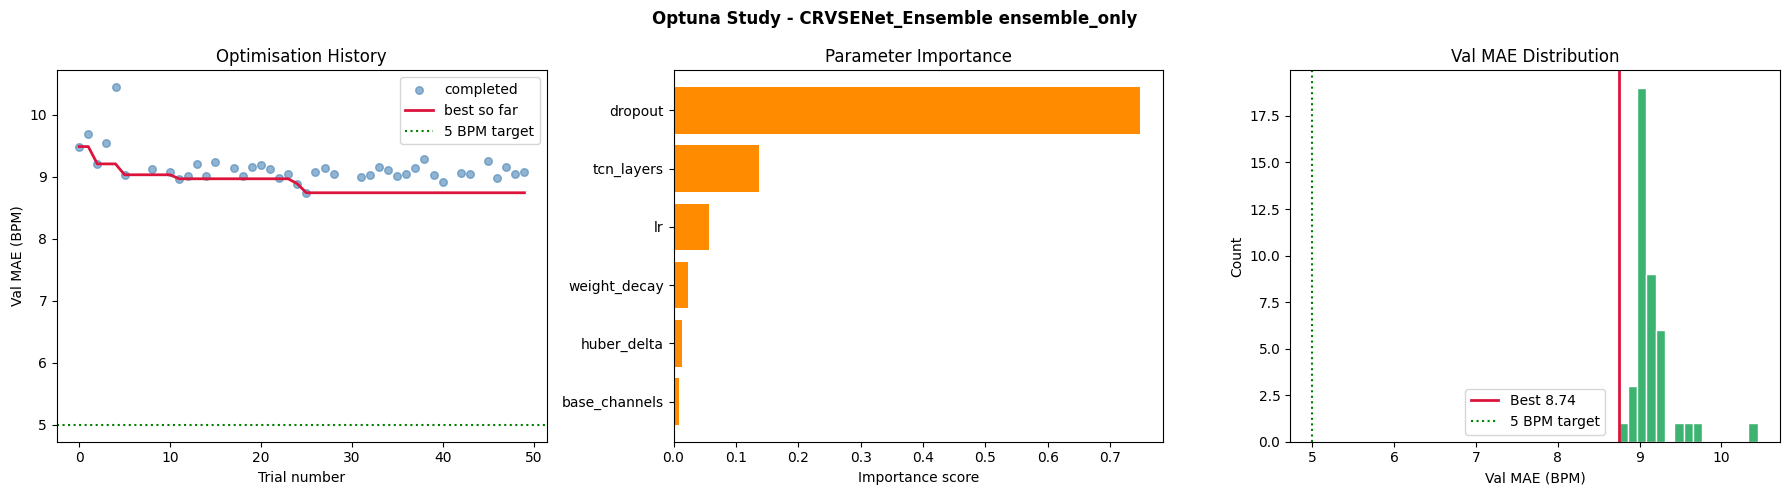

Study 2 - multichannel:


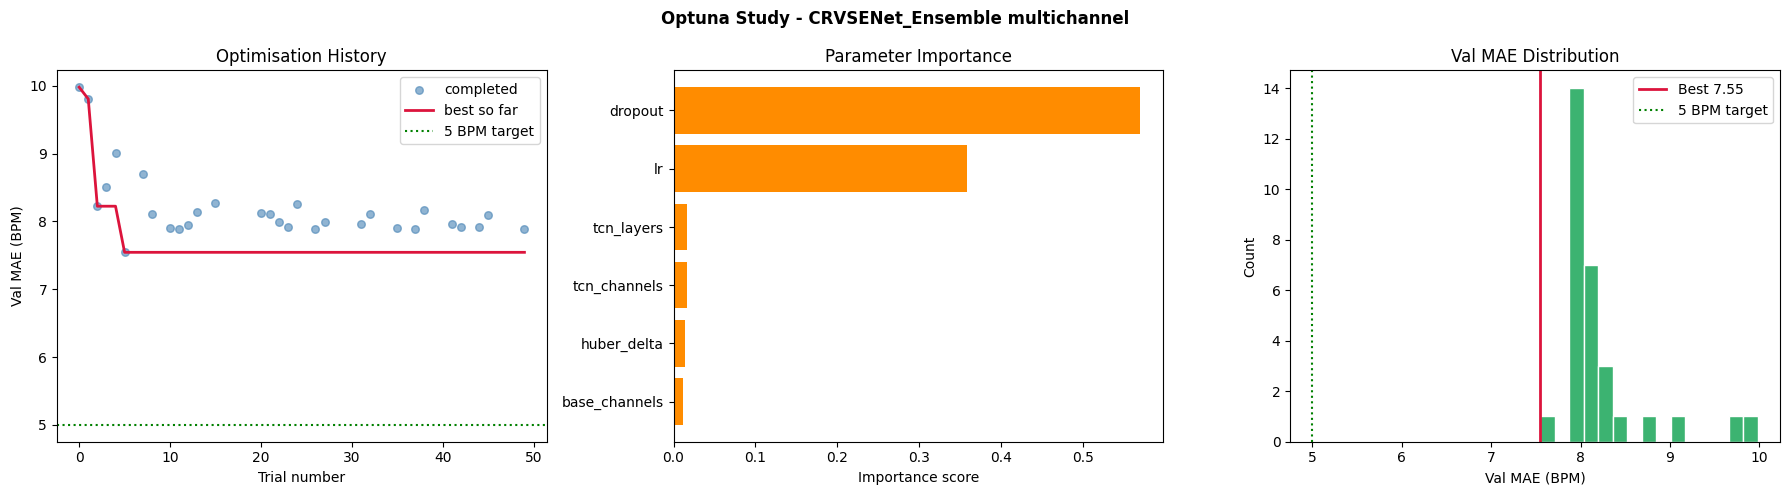


INPUT MODE COMPARISON
Mode                   Best val MAE   Best trial
------------------------------------------------
ensemble_only                8.74 BPM  #  25
multichannel                 7.55 BPM  #   5

Winner : multichannel (val MAE 7.55 BPM)
Proceeding to final training with multichannel configuration.


In [13]:
def plot_optuna_results(study: optuna.Study, model_name: str) -> None:
    trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    numbers = [t.number for t in trials]
    val_maes = [t.value for t in trials]
    best_so_far = np.minimum.accumulate([t.value for t in sorted(trials, key=lambda t: t.number)])

    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"Optuna Study - {model_name}", fontweight="bold")

    axes[0].scatter(numbers, val_maes, alpha=0.6, s=30, color="steelblue", label="completed")
    axes[0].plot(sorted(numbers), best_so_far, color="crimson", lw=2, label="best so far")
    axes[0].axhline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[0].set_xlabel("Trial number")
    axes[0].set_ylabel("Val MAE (BPM)")
    axes[0].set_title("Optimisation History")
    axes[0].legend()

    try:
        importances = optuna.importance.get_param_importances(study)
        top_params = list(importances.items())[:6]
        params, imps = zip(*top_params)
        axes[1].barh(params, imps, color="darkorange")
        axes[1].set_xlabel("Importance score")
        axes[1].set_title("Parameter Importance")
        axes[1].invert_yaxis()
    except Exception:
        axes[1].text(0.5, 0.5, "Importance\nnot available", ha="center", va="center", transform=axes[1].transAxes)

    axes[2].hist(val_maes, bins=15, color="mediumseagreen", edgecolor="white")
    axes[2].axvline(study.best_value, color="crimson", lw=2, label=f"Best {study.best_value:.2f}")
    axes[2].axvline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[2].set_xlabel("Val MAE (BPM)")
    axes[2].set_ylabel("Count")
    axes[2].set_title("Val MAE Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


print("Study 1 - ensemble_only:")
plot_optuna_results(study_1, f"{MODEL_NAME} ensemble_only")

print("Study 2 - multichannel:")
plot_optuna_results(study_2, f"{MODEL_NAME} multichannel")

# Comparision table 
print()
print("=" * 60)
print("INPUT MODE COMPARISON")
print("=" * 60)
print(f"{'Mode':<20} {'Best val MAE':>14} {'Best trial':>12}")
print("-" * 48)
for mode, study in [(INPUT_MODE_1, study_1), (INPUT_MODE_2, study_2)]:
    print(f"{mode:<20} {study.best_value:>12.2f} BPM  #{study.best_trial.number:>4}")
print()

# Select winning study for final training
if study_1.best_value <= study_2.best_value:
    BEST_STUDY = study_1
    BEST_INPUT_MODE = INPUT_MODE_1
    BEST_IN_CHANNELS = IN_CHANNELS_1
    BEST_TRAIN_DS = train_ds_1
    BEST_VAL_DS = val_ds_1
else:
    BEST_STUDY = study_2
    BEST_INPUT_MODE = INPUT_MODE_2
    BEST_IN_CHANNELS = IN_CHANNELS_2
    BEST_TRAIN_DS = train_ds_2
    BEST_VAL_DS = val_ds_2

print(f"Winner : {BEST_INPUT_MODE} (val MAE {BEST_STUDY.best_value:.2f} BPM)")
print(f"Proceeding to final training with {BEST_INPUT_MODE} configuration.")

## 13. Final Training on Best Configuration

Retrains on train + val combined using the winning study's best hyperparameters. Evaluates on held-out test set.

In [14]:
best_n_epochs = BEST_STUDY.best_trial.last_step
p = BEST_STUDY.best_params

print("=" * 55)
print(f"Retraining {MODEL_NAME} ({BEST_INPUT_MODE})")
print(f"Best trial: #{BEST_STUDY.best_trial.number}")
print(f"Best n_epoch: {best_n_epochs}")
print("=" * 55)

best_model = CRVSENet(
    in_channels = BEST_IN_CHANNELS,
    base_channels = p["base_channels"],
    tcn_channels = p["tcn_channels"],
    tcn_layers = p["tcn_layers"],
    tcn_kernel = p["tcn_kernel"],
    dropout = p["dropout"],
    hr_min = HR_MIN,
    hr_max = HR_MAX
).to(DEVICE)

# Train on train + val combined
full_ds = CRVSEDataset(all_samples, train_keys | val_keys, input_mode=BEST_INPUT_MODE)
full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)

print(f"Full train set: {len(full_ds)} windows")

loss_function = nn.HuberLoss(delta=p["huber_delta"])
optimizer = AdamW(best_model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=best_n_epochs, eta_min=p["lr"]/100)

epoch_bar = tqdm(range(1, best_n_epochs + 1), desc=f"Final Training {MODEL_NAME}", unit="epoch")
for epoch in epoch_bar:
    best_model.train()
    total_loss = 0.0
    for signals, labels in full_loader:
        signals, labels = signals.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        preds = best_model(signals)
        loss = loss_function(preds, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    epoch_bar.set_postfix({"loss" : f"{total_loss / len(full_loader):.3f}"})

# Test evaluation
test_ds = CRVSEDataset(all_samples, test_keys, input_mode=BEST_INPUT_MODE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

best_model.eval()
all_preds, all_labels = [], [] 

with torch.inference_mode():
    for signals, labels in test_loader:
        preds = best_model(signals.to(DEVICE)).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

all_subject_ids = [test_ds.items[i]["subject_key"] for i in range(len(test_ds))]
all_dataset_ids = [test_ds.items[i]["dataset"] for i in range(len(test_ds))]
preds_np = np.array(all_preds,  dtype=np.float32)
labels_np = np.array(all_labels, dtype=np.float32)

save_name = f"{MODEL_NAME}_{BEST_INPUT_MODE}_best.pt"
full_evaluation(preds_np, labels_np, all_subject_ids, all_dataset_ids, model_name=f"{MODEL_NAME} - {BEST_INPUT_MODE}")

torch.save(best_model.state_dict(), save_name)
print(f"\nSaved -> {save_name}")


Retraining CRVSENet_Ensemble (multichannel)
Best trial: #5
Best n_epoch: 50
Dataset size: 15946 windows (mode=multichannel)
Full train set: 15946 windows


Final Training CRVSENet_Ensemble: 100%|██████████| 50/50 [10:13<00:00, 12.28s/epoch, loss=30.942]

Dataset size: 3106 windows (mode=multichannel)



FULL EVALUATION - CRVSENet_Ensemble - multichannel

Window-level (n=3106 windows):
MAE : 7.78 BPM
RMSE : 11.62 BPM
MAPE : 9.11 %
Pearson r : 0.7401  (p=0.0000)
R² : 0.4979
BA bias : -3.44 BPM
BA LoA : [-25.20, 18.32] BPM

|error| <  5 BPM : 50.9% of windows
|error| < 10 BPM : 73.4% of windows
|error| < 15 BPM : 85.0% of windows

Subject-level metrics (n=52 subjects):
MAE : 4.93 BPM
RMSE : 7.94 BPM
r : 0.9028
BA bias: -3.63 BPM
BA LoA : [-17.47, 10.20] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
ecg_fitness       278    20.15    26.00   0.3511
mcd_rppg         2094     5.95     8.20   0.8355
ubfc_phys         658     8.78    11.59   0.1823
ubfc_rppg          76     4.44     5.46   0.9760

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          370     6.79    10.70
normal low              1657     5.67     7.67
normal high